# Exercise 1 for the class EE-568 Theory and Methods of Reinforcement Learning taught at EPFL in Spring 2026 by Prof. Volkan Cevher

### Names and Sciper numbers

#### Group Member 1:
Name: Emma Radoslavova Anastassova

Sciper number: 414901

#### Group Member 2:
Name: Mattea Busato

Sciper number: 408744

#### Group Member 3:
Name: Taliesin Perez

Sciper number: 357587

#### Group Member 4:
Name: Simon David Guillaume Jacques PIERRE

Sciper number: 345594

### LLM Usage

You are encouraged **not to use** LLMs or other AI tools so that you can fully engage with and learn the course material. Uploading the full document or copy-pasting the questions into an AI tool are strictly not allowed. 

If you do use them at any point, please clearly and transparently disclose what tool was used, and how in the next cell. 

If AI use is suspected but not clearly explained, we reserve the right to ask follow-up questions to clarify your understanding of the work. 

In [1]:
import os
from typing import List

import numpy as np
import tqdm

os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
import sys

sys.path.insert(0, "src/")
from environment import GridWorldEnvironment
from MDPsolver import MDPsolver
from plot import plot_log_lines, plot_lines
%load_ext autoreload
%autoreload 2

# Dynamic Programming exercise

We will make use of the operators introduced in the slides of lectures 1 and 2. 
$(T V)(s)$, $\mathcal{G}$ and $T^{\pi}$

Before diving into the implementation of Value Iteration or Policy Iteration, we instantiate an environment using the library in the foilder `src`.

The gridworld environment is instantiated via the class `GridWorldEnvironment`. It takes 4 input values:

- `reward_mode` : integer between 0 and 3 for different reward profiles
- `size`: Gridworld size
- `prop`: probability assigned to the event that the agent do not follow the chosen action but another one selected uniformely at random.
- `gamma`: the discount factor of the environment.

In [2]:
reward_mode = 2 # put an image to show which is the reward
size = 10 
prop = 0
gamma=0.99 # rename discount_factor
gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)

Below, we illustrate how to access the gridworld environment, i.e. how to access the reward, the transition matrix and the discount factor.

In [3]:
size = 3
gridworld_example = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)


***Interface with a Gridworld instance***
- `print(gridworld.n_states)` #return the number of states
- `print(gridworld.n_actions)` #return the number of actions
- `print(gridworld.r)` #return a matrix where each element indicates the reward corresponding to each (state, action) pair.
- `print(gridworld.gamma)` # return the discount factor
- `print(gridworld.sparseT[action])` #Input: action, Return: a matrix containing the state-to-state transition probabilities for the action passed as input.



<img src="src/vis_gridworld.png" alt="fishy" class="bg-primary" width="400px">

Then we set up the solver object that will implement the routine needed to evaluate the value of the produced policies

In [4]:
solver = MDPsolver(gridworld)

We will use this solver to compute the optimal value function to measure the suboptimality of the policies produced by value iteration or policy iteration.

To access the optimal value function use `solver.v`.

In [5]:
solver.value_iteration()

# Ex 1: Value Iteration [20 pts.]

### 1.1 Implement value iteration

In [6]:
def value_iteration(env, tol=1e-10):
    """Inplementation of value iteration, note that the implementation is based on value iteration mentioned in the lecture.
    Args:
        env: environment
        tol: a scalar to dermerminate whether the algorithm convergences
    Returns:
        policies: policy  at each iteration (list)
        vs: value functions at each iteration (list)
    """
    policies = []
    vs = []
    v = np.zeros(env.n_states) # initialize value function
    q = np.zeros((env.n_states, env.n_actions)) #initialize Q-value
    
    while True:
        v_old = np.copy(v) # save a copy of value function for the convergence criterion at the step
        for a in range(env.n_actions):
            q[:, a] = env.r[:, a] + env.gamma*(env.sparseT[a] @ v_old) # calculate Q-value
        v = np.max(q, axis=1) # update value function
        policies.append(np.argmax(q, axis=1)) # obtain policy
        vs.append(v)
        if np.linalg.norm(v - v_old) < tol: # convergence criterion
            break
    return policies, vs

In [7]:
policies, vs = value_iteration(gridworld)

### 1.2: Evaluate the extracted policies

For the evaluation of the sequence of policies, i.e. computing $V^\pi$ for each policy $\pi$ we recall that $V^\pi$ is the fixed point $V^\pi = T^\pi (V^\pi)$.
In the following code, we ask you to apply the operator $T^\pi$ a number of time sufficient to find a value $V$ such that $ || T^\pi(V) - V || \leq \mathrm{tol}$

In [8]:
def evaluate_policy_sequence(policies, env, tol=1e-10):
    """Inplementation of policy evaluation through iteratively applying policy value iteration 
    Args:
        policies: a list of policies obtained by section 1.1
        env: environment
        tol: a scalar to dermerminate whether the policy evaluation convergences
    Returns:
        values: a list of value function for each policy
    """
    values = []
    for pi in policies:
        v = np.zeros(env.n_states) # initialize value function
        q = np.zeros((env.n_states, env.n_actions)) #initialize Q-value
        while True:
            v_old = np.copy(v) # save a copy of value function for the convergence criterion at the step
            for a in range(env.n_actions):
                q[:, a] = env.r[:, a] + env.gamma * (env.sparseT[a] @ v) #calculate Q-value
            for s in range(env.n_states):
                action_taken = pi[s] # obtain the action determined by the policy
                v[s] = q[s, action_taken] #calculate value function by $v(s) = Q(s,pi(s))$
            if np.linalg.norm(v - v_old) < tol: # convergence criterion
                break
        values.append(v)
    return values

In [9]:
values = evaluate_policy_sequence(policies, gridworld)

### 1.3: Plot the results 

Plot using the method ```plot_lines(list_to_plot, list_name, axis_label, folder, title, x_axis = None, show = False) ```

Compute both the iterates $V_t$ produced by value iteration and the value function achieved by the extracted policies $V^{\pi_t}$ with $\pi_t = \mathcal{G}(V_t)$. What do you observe ?


**Answer:**

In the normal scale we see that:
- For value iteration:
    - The maximum absolute difference between the iterates and the solver solution $V^{\star}$ is negative, since the solution given by the solver is negative and the first iterate $V_0$ is initialized at 0. Therefore the iterates satisfy : $V_t \ge V^{\star}$.
    - The maximum absolute difference starts relatively small (around 120 in absolute value) and decreases monotonically in a smooth way towards 0.
    - The biggest drop (in terms of absolute difference) is after the first iteration, where the maximum absolute difference drops around 100 units.
- For the value function achieved by the extracted policies:
    - The maximum absolute difference between the solver solution and value function for the extracted policies starts much larger and positive, which means that the greedy policies obtained from the early value estimates are very suboptimal. Just after the first iteration, we observe a drop of around 600 units in terms of maximum absolute difference.
    - The convergence to the solver solution is less smooth, with big drops present (e.g. big drop at approximately the 8th iteration)

In the log scale we can more easily notice that:
- For value iteration:
    - The convergence curve is very smooth, with no jumps and looks like the graph of a C1 function (continuous and differentiable), which is consistent with the fact that $\mathcal{T}$ is a Lipshitz contraction. 
- For the value function achieved by the extracted policies:
    - The convergence trajectory is less smooth and seems to have jump discontinuities, which correspond to iterations where the greedy policy improves significantly.
    - It looks to have a maximum absolute difference a full order of magnitude higher than the value iteration curve for most of the iterations, but it does converge slightly earlier at the end.

In [10]:
def compute_subopt(values, v_star):
    """
    Args:
        values: a list of value function.
        v_star: the optimal value function obtained by MDP.solver
    Returns:
        subopts: an array indicates the suboptimality.
    """
    subopts = []
    for v in values:
        i = np.argmax(np.abs(v - v_star))
        subopts.append(-v[i] + v_star[i])
    return np.array(subopts)

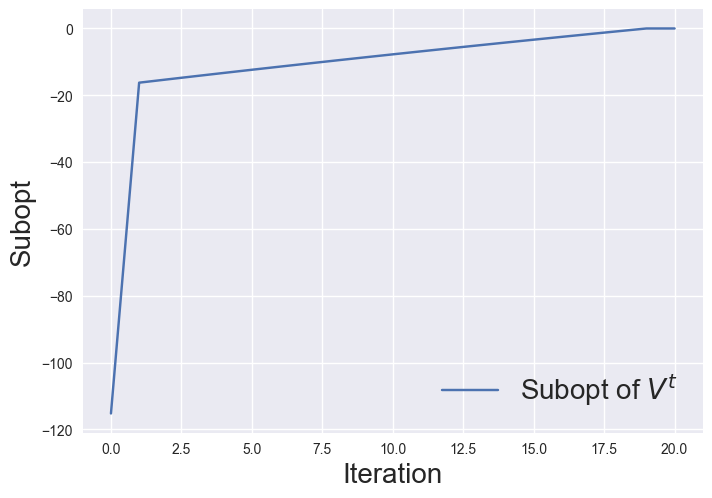

In [11]:
plot_lines([compute_subopt(vs, solver.v)], [r"Subopt of $V^t$"], ["Iteration", "Subopt"], "figs", "VI.pdf", show = True)

**Question** : 
- Prove that $T$ is a contraction, that is $|| T(V) - T(V') ||_{\infty} \leq \gamma || V - V' ||_{\infty}$.
- Why the iterates of Value Iterations are an upper bound to $V^\star$ ? How is this possible considering that $V^\star \triangleq \max_{\pi \in \Pi} V^{\pi}$ ?

**Answers**

- **Q1** : **Proof:** 

    $$ |(TV')(s)-(TV)(s)| = \Bigg| \max_{a \in \mathcal A} \Bigg[ r(s,a) + \gamma \sum_{s'} P(s'|s,a) V'(s') \Bigg] - \max_{a' \in \mathcal A} \Bigg[ r(s,a') + \gamma \sum_{s'} P(s' | s,a') V(s') \Bigg] \Bigg|$$
    $$ \leq \max_{a \in \mathcal{A}} \Bigg| \Bigg(r(s,a) + \gamma \sum_{s'} P(s' | s,a)V'(s') \Bigg) - \Bigg(r(s,a) + \gamma \sum_{s'} P(s' | s,a) V(s')\Bigg) \Bigg| $$
    $$ = \max_{a \in \mathcal{A}} \Bigg| \gamma \sum_{s'} P(s' |s,a)(V'(s')-V(s')) \Bigg| $$
    $$ \leq \max_{a \in \mathcal{A}} \gamma \sum_{s'} P(s'|s,a) |V'(s')-V(s')| $$
    $$ \leq \gamma \max_{a \in \mathcal{A}} \sum_{s'} P(s'|s,a) || V'-V||_{\infty}$$
    $$ =\gamma ||V'-V||_{\infty}$$

- **Q2** : By definition, $V^\star \triangleq \max_{\pi \in \Pi} V^{\pi}$, which means that $V^{\star}$ is the maximum value achievable by any policy $\pi$ and gives the upper bound: $\forall s \in S, V^{\pi}(s) \le V^{\star}(s)$. However, the intermediate value function iterates obtained when running Value Iteration (VI) are not value functions of any policy, thus they are not necessarily upper bounded by $V^{\star}$. The iterates only respect a given policy $\pi$ at convergence. Furthermore, by a simple check we can see that $V^{\star}$ returned by the solver is negative and since we initialize $V_0 = 0$ in VI, initially we have $V_0(s) \ge V^{\star}(s)$. $V_0$ is just an initial approximation of the value function, it does not correspond to any policy, so there is no contradiction. Since the Bellman optimality operator is monotone and has $V^{\star}$ as its fixed point, the intermediate iterates $V_k$ in VI converge to $V^{\star}$ from above.

<>:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/var/folders/3r/zftwt15d1xjg4jt1nztmv7p40000gn/T/ipykernel_16293/2314215747.py:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  plot_lines([compute_subopt(values, solver.v)], ["Subopt of $V^{\pi_t}$"], ["Iteration", "Subopt"], "figs", "VI.pdf", show = True)


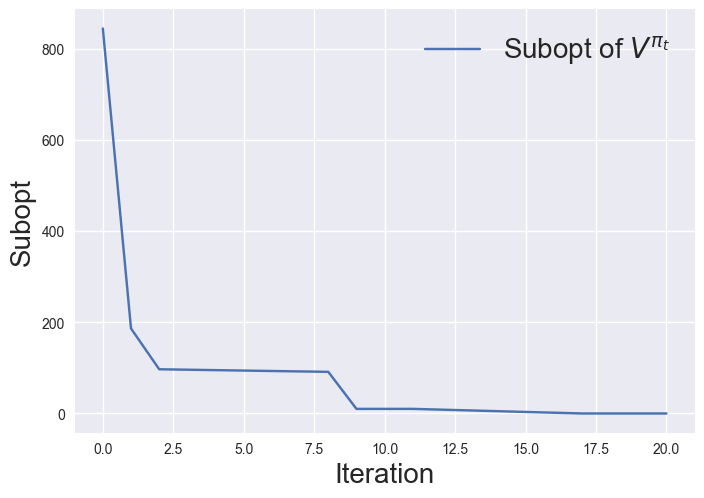

In [12]:
plot_lines([compute_subopt(values, solver.v)], ["Subopt of $V^{\pi_t}$"], ["Iteration", "Subopt"], "figs", "VI.pdf", show = True)

To better appreciate the difference in the convergence plot use log scale.

<>:2: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:2: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/var/folders/3r/zftwt15d1xjg4jt1nztmv7p40000gn/T/ipykernel_16293/126775526.py:2: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  [r"Subopt of $V^t$", "Subopt of $V^{\pi_t}$"],


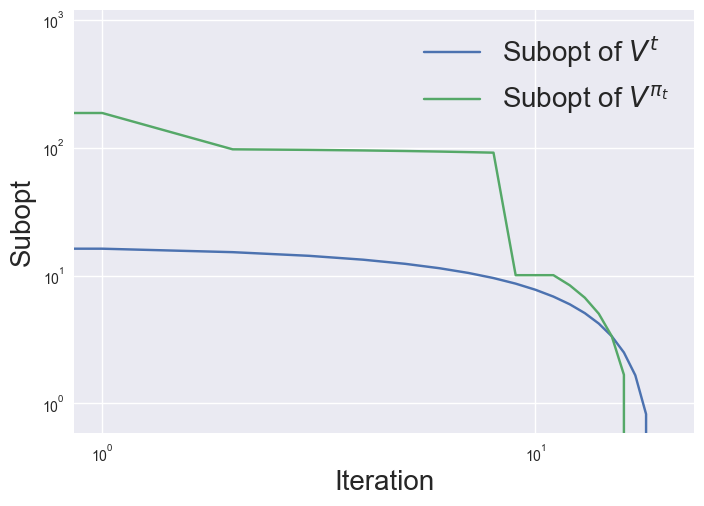

In [13]:
plot_log_lines([-compute_subopt(vs, solver.v), compute_subopt(values, solver.v)], 
               [r"Subopt of $V^t$", "Subopt of $V^{\pi_t}$"], 
               ["Iteration", "Subopt"], "figs", "VI.pdf", show = True)

# Ex 2: Policy Iteration [20 pts.]

In [14]:
def evaluate_policy(pi, env, tol=1e-10):
    """Implementation of policy evaluation through iteratively applying using a certain policy 
    Args:
        pi: a policy
        env: environment
        tol: a scalar to dermerminate whether the policy evaluation convergences
    Returns:
        v: an array with the values of the actions chosen
        q: an array with the q values    
    """
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    while True:
        v_old = np.copy(v)
        for a in range(env.n_actions):
            q[:, a] = env.r[:, a] + env.gamma*(env.sparseT[a]@v)
        for s in range(env.n_states):
            v[s] = q[s, pi[s]]
        if np.linalg.norm(v - v_old) < tol:
            break
    return v, q

In [15]:
def get_greedy_policy(q):
    """Implementation of a greedy approach to choose policies (policy improvement)
    Args:
        q: q values obtained from evaluating the policies
    Returns:
        policy: greedy policy (list)
    """
    policy = []
    for s in range(q.shape[0]):
        policy.append(np.argmax(q[s, :]))
    return policy

In [16]:
def policy_iteration(env, tol=1e-20):
    """Implementation of policy iteration
    Args:
        env: environment
        tol: a scalar to dermerminate whether the algorithm convergences
    Returns:
        vs: value functions at each iteration (list)
    """
    vs = []
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    pi = np.zeros(env.n_states, dtype=int)
    while True:
        v_old = np.copy(v)
        v, q = evaluate_policy(pi, env, tol)
        pi = get_greedy_policy(q)
        vs.append(v)
        if np.linalg.norm(v - v_old) < tol:
            break
    return vs, pi

In [17]:
values_pi, _ = policy_iteration(gridworld)

<>:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/var/folders/3r/zftwt15d1xjg4jt1nztmv7p40000gn/T/ipykernel_16293/1006779507.py:1: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  plot_lines([compute_subopt(values_pi, solver.v)], ["Subopt of $V^{\pi_t}$"], ["Iteration", "Subopt"], "figs", "VI.pdf", show = True)


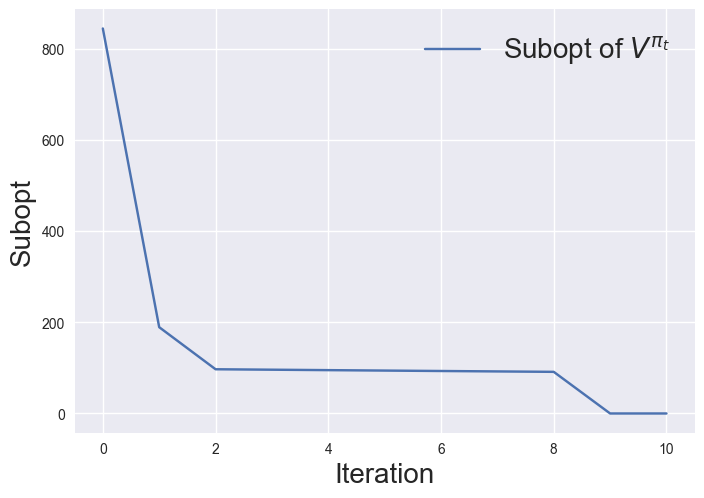

In [18]:
plot_lines([compute_subopt(values_pi, solver.v)], ["Subopt of $V^{\pi_t}$"], ["Iteration", "Subopt"], "figs", "VI.pdf", show = True)

### Compare with Value Iteration

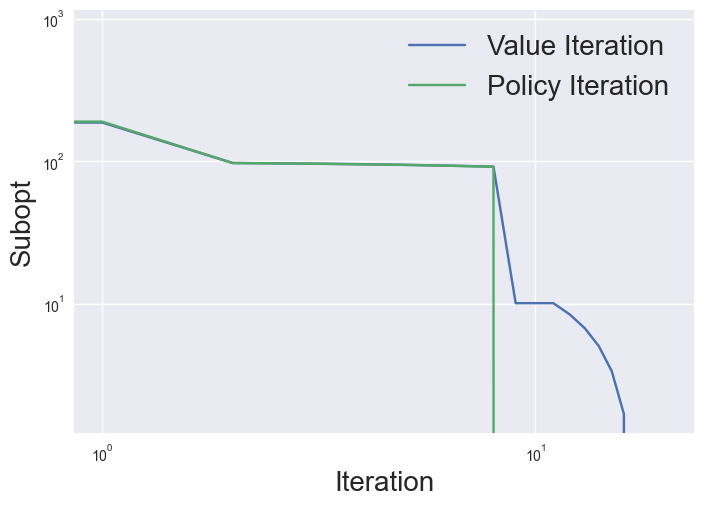

In [19]:
plot_log_lines([compute_subopt(values, solver.v), compute_subopt(values_pi, solver.v)], 
               ["Value Iteration", "Policy Iteration"], 
               ["Iteration", "Subopt"], "figs", "VIvsPI.pdf", show = True)

***Questions :*** 
- Which algorithm converges faster ?
- Is it theoretically expected ? Answer listing the expected number of iterations needed for VI and PI to converge ?


***Answers***

- Policy Iteration converges faster to 0.
- No, it is not expected, looking at the worst-case convergence bounds. In theory, VI converges in $\mathcal{O}(\frac{\text{log}(\epsilon(1-\gamma))}{\text{log}(\gamma)})$ iterations, in our case ($\gamma = 0.99$, $\epsilon = 10^{-10}$) this is $\mathcal{O}(\frac{\text{log}(10^{-12})}{\text{log}(0.99)}) = \mathcal{O}(2749)$. For PI this is $\mathcal{O}(\frac{|\mathcal{S}|(|\mathcal{A}|-1)}{1-\gamma}) = \mathcal{O}(\frac{300}{0.01}) = \mathcal{O}(30000)$, since $|\mathcal{S}| = 100,|\mathcal{A}| = 4$. For PI, this upper bound is usually loose and predicts significantly more iterations than the ones that are usually observed. In practice, it is usually faster than VI, due to the separation of policy evaluation and policy improvement, which leads to larger improvements per iteration, while in VI these improvements are incremental.

***Theory Questions*** 
- Prove the policy improvement theorem.
- Prove that the Bellman operator is monotone elementwise. That is if $V > V'$, then for any $\pi$, $T_{\pi}(V) > T_{\pi}(V')$.

***Answers***

1. **Policy improvement theorem** : 
Let $\pi'$ be a deterministic policy.
If $Q^{\pi}(s, \pi'(s)) \ge V^{\pi}(s) \quad \forall s \in S,$ then $V^{\pi'}(s) \ge V^{\pi}(s) \quad \forall s \in S$.

    **Proof** : 
$$
\begin{aligned}
V^\pi(s) &\leq Q^\pi(s, \pi'(s)) \\
&= \mathbb{E}_{\pi'} [r(s_0, \pi'(s_0)) + \gamma V^\pi(s_1) \mid s_0 = s] \\
&\leq \mathbb{E}_{\pi'} [r_0 + \gamma Q^\pi(s_1, \pi'(s_1)) \mid s_0 = s] \\
&\leq \mathbb{E}_{\pi'} [r_0 + \gamma r_1 + \gamma^2 V^\pi(s_2) \mid s_0 = s] \\
&\leq \dots \\
&\leq \mathbb{E}_{\pi'} [r_0 + \gamma r_1 + \gamma^2 r_2 + \dots \mid s_0 = s] \\
&= V^{\pi'}(s).
\end{aligned}
$$
2. **Monotone proof** : 
- $T^{\pi}$ is a contraction : $||T^\pi V' - T^\pi V||_\infty = \gamma |P^\pi (V-V')||_\infty \leq \gamma ||V-V'||_\infty$. 
- $T^{\pi}$ is monotone element-wise: Let $V' \le V$, i.e. $\forall s \in S : V'(s) \le V(s)$. By definition, $\mathcal{T}^{\pi} = R^{\pi} + \gamma P^{\pi} V$, where for any policy $\pi$, $P^{\pi}$ is a stochastic matrix. Taking an arbitrary $s \in S$ : $(\mathcal{T}^{\pi}V')(s) = R^{\pi}(s) + \gamma P^{\pi} V'(s) = R^{\pi}(s) + \gamma \sum_{s'} P^{\pi}(s,s') V'(s') \le R^{\pi}(s) + \gamma \sum_{s'} P^{\pi}(s,s') V(s') = (\mathcal{T}^{\pi}V)(s)$. Hence when $V' \leq V, T^\pi V' \leq T^\pi V$ also holds. Thus $T^{\pi}$ is monotone element-wise.


# Ex 3: Modified Policy Iteration [20 pts.]

In this cell you will code and run Modified Value Iteration, that follows this pseudocode:
- $\pi_{k+1} = \mathcal{G}(V_k)$
- $V_{k+1} = T^m_{\pi_{k+1}}(V_k)$

In the implementation, we will use also the variable $Q$ as in the previous implementation of VI and PI for convenience of implementation.

**Questions**

Which value of $m$ recovers policy iteration ?
Which value of $m$ recovers value iteration ?

***Answers***

The value of $m$ that recovers policy iteration is $m = +\infty$, meaning that we perform policy evaluation until convergence for each policy before each greedy policy update. The value of $m$ that recovers value iteration is $m = 1$, meaning that we perform only one step of policy evaluation before updating the policy by taking a greedy step.

First, write a function that applies the Bellman evaluation operator $m$ times

In [20]:
def policy_operator_m_times(pi, m, env, v, q):
    """Implementation of partial policy evaluation through applying m times the Bellman operator
    Args:
        pi: a policy
        env: environment
        tol: a scalar to dermerminate whether the policy evaluation convergences
        v: initial value vector
        q: initial state action value vector
    Returns:
        v: an array with the values of the actions chosen
        q: an array with the q values    
    """
    i = 0
    while i < m:
        for a in range(env.n_actions):
            q[:, a] = env.r[:, a] + env.gamma * (env.sparseT[a] @ v)
        for s in range(env.n_states):
            v[s] = q[s, pi[s]]
        i = i + 1
    return v, q

At this point, using the function `get_greedy_policy` implemented for PI you are ready to implement Modified Policy Iteration !

In [21]:
def modified_policy_iteration(env, m, tol=1e-10):
    """Implementation of modified policy iteration
    Args:
        env: environment
        tol: a scalar to dermerminate whether the algorithm convergences
    Returns:
        vs: value functions at each iteration (list)
    """
    vs = []
    policies = []
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    pi = np.zeros(env.n_states, dtype=int)
    while True:
        v_old = np.copy(v)
        pi = get_greedy_policy(q)
        v, q = policy_operator_m_times(pi, m, env, v, q)
        policies.append(pi)
        vs.append(v)
        if np.linalg.norm(v - v_old) < tol:
            break
    return vs,policies

Now run modified policy iteration for different values of $m$ for example between $1$ and $10$. 

In [22]:
m_values = ["1", "2", "3", "5", "10", "20"]
to_plot = []
for m in m_values:
    m = int(m)
    _, policies_mpi=modified_policy_iteration(gridworld, m)
    values_mpi = evaluate_policy_sequence(policies_mpi, gridworld)
    to_plot.append(compute_subopt(values_mpi, solver.v))

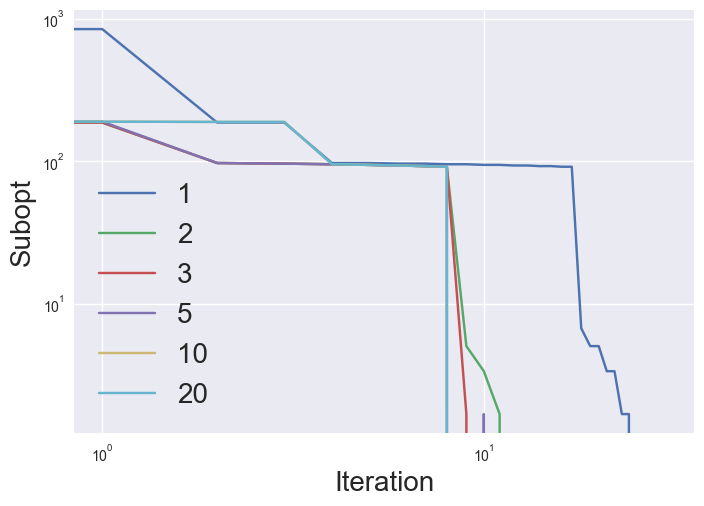

In [23]:
plot_log_lines(to_plot, 
           m_values, 
           ["Iteration", "Subopt"], "figs", "MPI.pdf", show = True)

**Questions** 
- How does the value of $m$ affect convergence ?
- Which is the cost per iteration of Modified Policy Iteration ?
- Which is the cost per iteration of Policy Iteration implemented with Option 2 in the slides ?

***Answers***

- The higher the m the less iterations we need to converge. This is easily seen if we look at the graph and compare the convergence curves for $m=1$ and $m=20$, the second one converging in visibly fewer iterations. This is consistent with the result found earlier, that PI converges faster (i.e. in fewer iterations) than VI in practice, despite having a higher worst-case upper bound, as PI is equivalent to MPI with $m=+\infty$.
- Per iteration cost of Modified PI : $\mathcal{O}(m|\mathcal{S}|^2|\mathcal{A}|)$, since we apply the Bellman operator m times. We plug in $|\mathcal{S}| = 100$ and $|\mathcal{A}|=4$ (which we find by calling 'gridworld.n_states' and 'gridworld.n_actions'), getting $\mathcal{O}(40000m)$.
- PI with option 2 : the cost of inverting a $|\mathcal{S}| \times |\mathcal{S}|$ matrix is $\mathcal{O}(|\mathcal{S}|^3)$, while matrix-vector multiplication between a $|\mathcal{S}| \times |\mathcal{S}|$ matrix and a $|\mathcal{S}|$-component vector is $\mathcal{O}(|\mathcal{S}|^2)$, hence the total cost of solving the linear system is $\mathcal{O}(|\mathcal{S}|^3 + |\mathcal{S}|^2) = \mathcal{O}(|\mathcal{S}|^3)$. The policy improvement step still costs $\mathcal{O}(|\mathcal{S}|^2|\mathcal{A}|)$, hence the total cost per iteration is $\mathcal{O}(|\mathcal{S}|^3 + |\mathcal{S}|^2|\mathcal{A}|)$ This is more expensive per iteration than MPI, but takes less steps to converge.

In [24]:
print(gridworld.n_actions)
print(gridworld.n_states)

4
100


# Ex 4: Q-Learning [20 pts.]

Now, we are ready to tackle the problem in the model free setting. For technical reason, we focus on the finite horizon setting in this part and we compare two exploration strategies.
1. **$\varepsilon$-greedy** (Watkins, Christopher John Cornish Hellaby. “Learning from Delayed Rewards.” PhD Thesis, King’s College, Cambridge United Kingdom, 1989.)
  - Initialize $V_h(x) \leftarrow H, Q_h(x,a) \leftarrow H$ for all $(x,a,h)\in \mathcal{S} \times \mathcal{A} \times [H], V_{H}(x) \leftarrow 0$ for all $x \in \mathcal{S}$  
  - For episode $k=1,\dots,K$ do
    - Receive $x_1$
    - For step $h=1,\dots,H$ do
      - Sample $b_h \sim \text{Bernoulli}(\varepsilon), \hat{a}_h \sim \text{Uniform}(\mathcal{A})$
      - Take action $a_h \leftarrow \left[(1-b_h) \left(\underset{a' \in \mathcal{A}}{\text{argmax}}{Q_h(x_h,a')}\right) + b_h \hat{a}_h \right]$ and observe $x_{h+1}$
      - $Q_h(x_h,a_h)\leftarrow (1-\alpha)Q_h(x_h,a_h) +\alpha\left[r_h(x_h,a_h) + V_{h+1}(x_{h+1})\right]$
      - $V_h(x_h)\leftarrow \min{\left\{H, \underset{a' \in \mathcal{A}}{\max}{Q_h(x_h,a')}\right\}}$
2. **UCB bonuses** (Jin, Chi, Zeyuan Allen-Zhu, Sebastien Bubeck, and Michael I Jordan. “Is Q-Learning Provably Efficient?” In Advances in Neural Information Processing Systems, Vol. 31. Curran Associates, Inc., 2018. https://arxiv.org/abs/1807.03765 )
  - Initialize $V_h(x) \leftarrow H, Q_h(x,a) \leftarrow H$ and $N_h(x,a) \leftarrow 0$ for all $(x,a,h)\in \mathcal{S} \times \mathcal{A} \times [H], V_{H}(x) \leftarrow 0$ for all $x \in \mathcal{S}$  
  - For episode $k=1,\dots,K$ do
    - Receive $x_1$
    - For step $h=1,\dots,H$ do
      - Take action $a_h \leftarrow \underset{a' \in \mathcal{A}}{\text{argmax}}{Q_h(x_h,a')}$ and observe $x_{h+1}$
      - $t=N_h(x_h,a_h)\leftarrow N_h(x_h,a_h) + 1, \alpha_t = \frac{H+1}{H+t}$ and $b_t \leftarrow c\sqrt{\frac{H^3}{t}}$
      - $Q_h(x_h,a_h)\leftarrow (1-\alpha_t)Q_h(x_h,a_h) +\alpha_t\left[r_h(x_h,a_h) + V_{h+1}(x_{h+1}) + b_t\right]$
      - $V_h(x_h)\leftarrow \min{\left\{H, \underset{a' \in \mathcal{A}}{\max}{Q_h(x_h,a')}\right\}}$

For other technical reason, we also need to rescale the reward between 0 and 1, as done in the following

In [25]:
reward_mode = 0
size = 10
gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)
r_max = np.max(gridworld.r)
r_min = np.min(gridworld.r)
gridworld.r = (gridworld.r - r_min) / (r_max - r_min)

### Q learning with epsilon greedy 

In this subsection, we implement $Q$ Learning with the simplest possible exploration strategy: $\epsilon$-greedy.

In [26]:
def argmax_with_random_tie_breaking(b):
    return np.random.choice(np.where(b == b.max())[0])

In [27]:
def q_learning_epsilon_greedy(K: int = 100000, H: int = 20, epsilon: float = 0.1, alpha: float = 0.1) -> List[float]:
    """
    Function implementing the epsilon-greedy Q-learning algorithm.

    :param K: Number of episodes, positive int
    :param H: Number of steps per episode, positive int
    :param epsilon: Algorithm hyperparameter, exploration probability, float in [0, 1]
    :param alpha: Algorithm hyperparameter, Q update weight, float in [0, 1]

    :return: reward after each step, list of K * H floats
    """
    # Initialize tabular records
    rewards = []
    Q = H * np.ones((H, gridworld.n_states, gridworld.n_actions))
    V = H * np.ones((H + 1, gridworld.n_states))
    V[H, :] = 0

    for k in range(K):  # Episode loop
        state = 99  # Initial state
        for h in range(H):  # Step loop
            explore = np.random.binomial(2, p=epsilon)
            if explore:
                # Exploration: With probability epsilon take a random action
                a = np.random.choice(gridworld.n_actions)
            else:
                # Exploitation: With probability 1 - epsilon take one of the optimal actions for the current state
                a = argmax_with_random_tie_breaking(Q[h, state, :])

            # Get reward for action
            rewards.append(gridworld.r[state, a])

            # Get the new state according to the transition dynamics
            new_state = np.random.choice(gridworld.n_states,
                                         p=gridworld.T[a][state])

            # Update Q according to the algorithm
            Q[h, state, a] = (1-alpha)*Q[h, state,a] + alpha*(gridworld.r[state, a] + V[h + 1, new_state])

            # Update V as the Q-value of the optimal actions for the current state
            V[h, state] = np.min([np.max(Q[h, state, :]), H])

            state = new_state
    return rewards

In [28]:
reward_eps_greedy = q_learning_epsilon_greedy()  # You can play around with the arguments if you like
cumulative_reward_eps_greedy = np.cumsum(reward_eps_greedy)

### Q-Learning with bonuses

In this subsection, you are asked to implement an optimistic version of  Q Learning suggested in (Jin et al., 2018)

In [29]:
def q_learning_ucb_bonuses(K: int = 100000, H: int = 20, c: float = 0.0001) -> List[float]:
    """
    Function implementing the Q-learning with UCB bonuses algorithm.

    :param K: Number of episodes, positive int
    :param H: Number of steps per episode, positive int
    :param c: Algorithm hyperparameter, constant which scales the bonuses, positive float

    :return: reward after each step, list of K * H floats
    """

    # Initialize tabular records
    rewards = []
    Q = H * np.ones((H, gridworld.n_states, gridworld.n_actions))
    V = H * np.ones((H + 1, gridworld.n_states))
    V[H, :] = 0
    N = np.ones((H, gridworld.n_states, gridworld.n_actions))

    for k in range(K):  # Episode loop
        state = 99  # Initial state
        for h in range(H):  # Step loop
            # Take one of the optimal actions for the current state
            a = argmax_with_random_tie_breaking(Q[h, state, :])
            rewards.append(gridworld.r[state, a])

            # Record that we visited this state-action pair (again)
            N[h, state, a] += 1

            # Get the new state according to the transition dynamics
            new_state = np.random.choice(gridworld.n_states,
                                         p=gridworld.T[a][state])

            # Calculate the UCB bonus
            bonus = c * np.sqrt(H ** 3 / N[h, state, a])

            # Calculate the adaptive alpha according to the algorithm
            alpha = (H + 1) / (H + N[h, state, a])

            # Update Q according to the algorithm
            Q[h, state, a] = (1-alpha)*Q[h, state,a] + alpha*(gridworld.r[state,a] + V[h + 1, new_state] + bonus)
            # Update V as the Q-value of the optimal actions for the current state
            V[h, state] = np.max(Q[h, state, :])
            V[h, state] = np.clip(V[h, state], 0, H)

            state = new_state

    return rewards

In [30]:
reward_UCB = q_learning_ucb_bonuses()  # You can play around with the arguments if you like
cumulative_reward_UCB = np.cumsum(reward_UCB)

### Comparison of exploration strategies

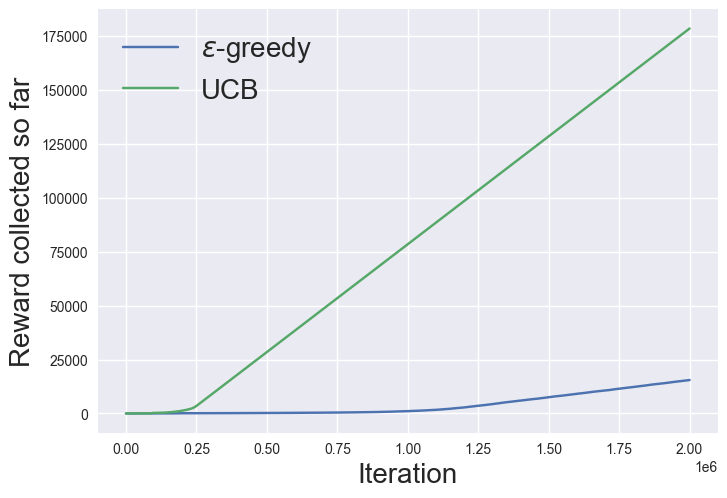

In [31]:
plot_lines(
    [cumulative_reward_eps_greedy, cumulative_reward_UCB],
    [r"$\epsilon$-greedy", "UCB"],
    ["Iteration", "Reward collected so far"],
    "figs",
    "ucbvseps",
    show=False
)

**Question:** You are given an environment with $N$ states linked in a chain, i.e. from every state except the two endpoints there are two possible actions going right or go back to the first state in the chain. For the endpoints the second action is to stay in the same state. The reward is only 1 if you are in the rightmost state and stay there, otherwise 0. What is the probability that the $\varepsilon$-greedy algorithm will have a positive reward after $H$ steps in the first episode, if the chosen initial state is the leftmost state in the chain? For simplicity you can consider the case $H=N$.

**Answer** : 
In the first episode, all Q-values are initialized to be equal, so each action among the ones available at a given state is taken with probability $\frac{1}{2}$. For instance, the probability of going right, given that we are not in the rightmost state is : 

$$\mathbb{P}(a = \text{move right}) = \mathbb{P}(a =\text{move right} | \text{exploitation})\mathbb{P}(\text{exploitation}) +\mathbb{P}(a=\text{move right}| \text{exploration}) \mathbb{P}(\text{exploration})=\frac{1}{2}(1-\epsilon) + \frac{1}{2}(\epsilon) = \frac{1}{2}$$

The same applies for the probability of staying in the rightmost state, given that we are in it. 
Moreover, actions are taken independently of one another, so to get the reward starting from the leftmost state, we need to move right $N-1$ times and stay there at the last step :
- $\mathbb{P}(\text{move right once} |  \text{not in rightmost state}) = \frac{1}{2}$
- $\mathbb{P}(\text{stay in rightmost state} |  \text{in rightmost state}) = \frac{1}{2}$

Thus the probability of getting the reward is : $p = (\frac{1}{2})^{N-1} \times \frac{1}{2} = (\frac{1}{2})^{N}$.

**Question:** Does the empirical result match the theoretical result described in (Jin et al. 2018) ? Try to answer this question after reading their Appendix A and looking at their Table 1 for the algorithm they call UCB-H.

Yes, the empirical results match:
- Q-learning with the $\epsilon$-greedy algorithm can take even an exponential number of episodes to learn since the regret is lower bounded by $\Omega(\min\{T, A^{H/2}\})$ (Table 1). As shown in Appendix A, in the combination lock MDP case, unless the algorithm picks the correct sequence of actions of length $\frac{H}{2}$, the Q-values are never updated, which happens with probability at most $A^{-H/2}$ and explains the regret lower bound. Indeed in the above plot the cumulative reward for the $\epsilon$-greedy simulation increases very slowly.
- instead Q-learning with UCB exploration should learn much faster, with the regret having an asymptotic behaviour of $\tilde{\mathcal O }(\sqrt(H^4SAT))$, i.e. sublinear $\sqrt{T}$ regret. Indeed in the above plot the cumulative reward increases very fast in the UCB simulation.

# Monte Carlo (MC) and Time Differences (TD) ( * Question ) [20 points]

Disclaimer: The TA can not help you on this part of the notebook.

In [32]:
def generate_episode(policy: List, H: int, initial_state: int):
    """
    Generate an episode using the given policy.

    :param policy: A list where each element is a probability distribution over actions for a state.
    :param H: Maximum number of steps in the episode.
    :param initial_state: Starting state.

    :return: A list of (state, action, reward) tuples.
    """
    episode = []
    state = initial_state
    for _ in range(H):
        action = policy[state]
        reward = gridworld.r[state, action]
        next_state = np.random.choice(gridworld.n_states, p=gridworld.T[action][state])
        episode.append((state, action, reward))
        state = next_state
    return episode

def mc_policy_evaluation_with_linear_approx(
    policy: List[np.ndarray], 
    phi: np.ndarray,
    K: int = 1000, 
    H: int = 20, 
    gamma: float = 0.99, 
    alpha: float = 0.01
) -> np.ndarray:
    """
    Monte Carlo policy evaluation with linear function approximation.

    :param policy: A list where each element is a probability distribution over actions for a state.
    :param K: Number of episodes.
    :param H: Maximum number of steps per episode.
    :param gamma: Discount factor.
    :param alpha: Learning rate for gradient descent.

    :return: The learned weight vector theta.
    """
    # Feature matrix: Each state is represented by a one-hot vector
    n_states = gridworld.n_states

    # Initialize weight vector theta
    theta = np.zeros(n_states)

    for _ in tqdm.tqdm(range(K)):  # Episode loop
        episode = generate_episode(policy, H, initial_state=99)  # Generate episode
        G = 0  # Return

        # Backward pass through the episode
        for t in range(len(episode) - 1, -1, -1):
            state, _, reward = episode[t]
            G = gamma * G + reward  # Discounted return

            # Update theta using gradient descent
            phi_s = phi[state]  # Feature vector for the current state
            V_hat = np.dot(theta, phi_s)  # Current value estimate
            theta += alpha*(G - V_hat)*phi_s  # Gradient descent update

    return theta


In [33]:

import numpy as np
def td_policy_evaluation_with_linear_approx(
    policy: List[np.ndarray], 
    phi: np.ndarray,
    K: int = 1000, 
    H: int = 20, 
    gamma: float = 0.99, 
    alpha: float = 0.01
) -> np.ndarray:
    """
    Temporal Difference (TD) policy evaluation with linear function approximation.

    :param policy: A list where each element is a probability distribution over actions for a state.
    :param K: Number of episodes.
    :param H: Maximum number of steps per episode.
    :param gamma: Discount factor.
    :param alpha: Learning rate for gradient descent.

    :return: The learned weight vector theta.
    """
    # Feature matrix: Each state is represented by a one-hot vector
    n_states = gridworld.n_states

    # Initialize weight vector theta
    theta = np.zeros(n_states)

    for _ in tqdm.tqdm(range(K)):  # Episode loop
        state = 99  # Initial state
        for _ in range(H):  # Step loop
            # Sample action from policy
            action = policy[state]
            reward = gridworld.r[state, action]
            next_state = np.random.choice(gridworld.n_states, p=gridworld.T[action][state])

            # Compute TD target and TD error
            phi_s = phi[state]  # Feature vector for current state
            phi_s_next = phi[next_state]  # Feature vector for next state
            V_s = np.dot(theta, phi_s)  # Current value estimate
            V_s_next = np.dot(theta, phi_s_next)  # Next value estimate
            td_target = reward + gamma*V_s_next # TD target
            td_error = td_target - V_s # TD error
            # Update theta using gradient descent
            theta += alpha*phi_s*td_error

            # Move to the next state
            state = next_state

    return theta

**Case 1:**

In [34]:
_, pi=policy_iteration(gridworld)

phi = np.eye(gridworld.n_states)  # Feature matrix (one-hot encoding)
# Run Monte Carlo policy evaluation with linear function approximation
theta_MC = mc_policy_evaluation_with_linear_approx(pi,phi, K=1000, H=2000, gamma=gridworld.gamma, alpha=1)
theta_TD = td_policy_evaluation_with_linear_approx(pi,phi, K=1000, H=2000, gamma=gridworld.gamma, alpha=1)

print(np.linalg.norm(theta_MC  - theta_TD))

100%|██████████| 1000/1000 [00:30<00:00, 33.11it/s]

8.919948611419325e-07


**Case 2:**

In [35]:
_, pi=policy_iteration(gridworld)

phi = np.eye(gridworld.n_states)  # Feature matrix (one-hot encoding)
phi[:50,:]*=0

# Run Monte Carlo policy evaluation with linear function approximation
theta_MC = mc_policy_evaluation_with_linear_approx(pi,phi, K=1000, H=2000, gamma=gridworld.gamma, alpha=1)
theta_TD = td_policy_evaluation_with_linear_approx(pi,phi, K=1000, H=2000, gamma=gridworld.gamma, alpha=1)

print(np.linalg.norm(theta_MC  - theta_TD))

100%|██████████| 1000/1000 [00:28<00:00, 34.94it/s]

190.43020836185028


**Questions:** 
- Does the solution coincide ( up to numerical error ) in Case 1? 
- Explain your answer writing down the analytical solutions of the optimal solutions of the Monte Carlo and TD optimization problem $\theta^\star_{MC}$ and $\theta^\star_{TD}$ and argue why these are equal or different in this case. To give this answer you can assume that $\rho$ is positive everywhere.

**Answers**


- Yes, the solutions coincide, with a numerical error of $8.9 \times 10^{-7}$, which is small enough to be neglected.
- Denote $\Phi$ the feature matrix and $D = diag(\rho)$ the matrix of state visitation frequencies.

MC computes the projection of $V^{\pi}$ onto the feature space and aims to minimize the MSE : 
$$ \text{min}_{\theta} \mathcal{L}(\theta) = \text{min}_{\theta} \frac{1}{2}\| \Phi\theta - V^{\pi} \|_{\rho}^2 = \text{min}_{\theta} \frac{1}{2}\ (\Phi\theta - V^{\pi})^{T}D(\Phi\theta - V^{\pi})$$
At the optimal solution $\theta^\star_{MC}$, the gradient of the loss is equal to 0, by first order optimality conditions : 
$$\nabla_{\theta}\mathcal{L}(\theta^\star_{MC}) = \Phi^{T}D(\Phi\theta^\star_{MC} - V^{\pi}) = 0$$
The optimal parameter can be found by solving a least squares problem :

$$\theta^\star_{MC}= (\Phi^{T}D\Phi)^{-1}\Phi^{T}D V^{\pi}$$

In TD, the optimal parameter satisfies the projected Bellman equation :

$$\Phi^{T}D(\Phi\theta_{TD}^{\star}- \mathcal{T}^{\pi}\Phi\theta_{TD}^{\star}) = 0$$

Rearranging : 
$$ \theta_{TD}^{\star} = (\Phi^{T}D\Phi)^{-1} \Phi^{T} D \mathcal{T}^{\pi}\Phi\theta_{TD}^{\star} $$

- $\Phi$ is here the identity matrix (full rank), and $\rho$ is positive everywhere, which means that the value function can be represented exactly by the LFA, since each state has its own feature. This means that
$V^\pi = \Phi\theta^\star$ has an exact solution and this is valid for both the MC and TD methods. Plugging $\Phi = I$ into the TD equation and simplifying, we get : 
$$\theta^\star_{TD} = (I^T D I)^{-1} I^T D \mathcal{T}^{\pi} \theta^\star_{TD} 
= \mathcal{T}^{\pi} \theta^\star_{TD}$$
So $\theta^\star_{TD}$ is the fixed point of $\mathcal{T}^\pi$, which is by 
definition $V^\pi$. Similarly, plugging in $\Phi = I$ for MC, the solution becomes:
$$\theta^\star_{MC} = (I^T D I)^{-1} I^T D V^\pi = V^\pi$$
Thus both methods obtain the same solution :
$$\theta^\star_{MC}= \theta^\star_{TD} = V^{\pi}$$

**Questions:** 
- Does the solution coincide ( up to numerical error ) in Case 2? 
- Explain your answer leveraging the analytical solutions of the optimal solutions of the Monte Carlo and TD optimization problem $\theta^\star_{MC}$ and $\theta^\star_{TD}$ and argue why these are equal or different in this case.
- Let $\Phi$ be the feature matrix. Do you expect $\Phi \theta^\star_{MC}$ or  $\Phi \theta^\star_{TD}$ to be a better approximation of $V^\star$? Point to a formal result in the lecture slides when giving your answer.

**Answers**
- No, the solutions of the TD and MC optimization problems do not coincide. Numerically, they differ by 190 units.

- In this case the feature matrix $\Phi$ is modified, so that the first 50 rows are 0, meaning its rank is not maximum (=misspecified setting). In turn, this means the value function approximation cannot exactly distinguish those states, so the true value function can't be represented exactly. Since $\Phi$ is rank deficient, the least squares projection onto the feature space is no longer unique. MC finds the closest approximation to $V^{\pi}$ directly,  while TD finds the fixed point of the projected Bellman equation (see the exact analytical solutions above).
Since the first 50 states have no features, TD's updates 
for those states rely only on their successors, which leads to propagation errors. It is not guaranteed that $\mathcal{T}^{\pi}\Phi\theta^\star_{TD}$ remains in the 
feature space. It is therefore expected that the two solutions are different.

- We expect $\Phi \theta^\star_{MC}$ to be a better approximation of $V^\star$ in this case. The lecture slides (slide 32, p.35) state that in the misspecified setting: 
$$ \| V_{\theta^\star_{TD}} - V^{\pi}\|_{\rho} \le \frac{1}{\sqrt{1-\gamma^2}} \| \Phi \theta^\star_{MC}- V^{\pi} \|_{\rho}$$

And that the minimum possible approximation error is achieved by the MC method.
